# Features exploration

In [182]:
# imports

from pathlib import Path # handling file paths

import numpy as np # numerical operations
import pandas as pd # CSV files

from scipy.signal import welch # spectral density estimation
from scipy.integrate import trapezoid # integration

import matplotlib.pyplot as plt # plotting

from tqdm.auto import tqdm # progress bars

from scipy.stats import mannwhitneyu # Mann-Whitney U test
from statsmodels.stats.multitest import multipletests # multiple comparisons correction

## 1.Settings

In [183]:
# paths

FEATURES_PATH = Path("outputs") / "eeg_features_data.csv"

print("Features file exists:", FEATURES_PATH.exists())
print("Path:", FEATURES_PATH)

# EEG channels, frequency bands and regions
EEG_CHANNELS = [
    "Fp1", "Fp2", "F3", "F4",
    "C3", "C4",
    "P3", "P4",
    "O1", "O2",
    "F7", "F8",
    "T7", "T8",
    "P7", "P8",
    "Fz", "Cz", "Pz"
]


Features file exists: True
Path: outputs\eeg_features_data.csv


In [184]:
# Pretty names for plots

FEATURE_LABELS = {
    "frontal_theta_power_mean": "Frontal " r"${\theta}$ power",
    "frontal_beta_power_mean": "Frontal " r"${\beta}$ power",
    "frontal_theta_beta_ratio": "Frontal " r"${\theta}/{\beta}$ ratio",
    "occipital_beta_power_mean": "Occipital " r"${\beta}$ power",
    "temporal_theta_beta_ratio": "Temporal " r"${\theta}/{\beta}$ ratio",
    "occipital_theta_beta_ratio": "Occipital " r"${\theta}/{\beta}$ ratio",
    "parietal_theta_beta_ratio": "Parietal " r"${\theta}/{\beta}$ ratio",
    "central_theta_beta_ratio": "Central " r"${\theta}/{\beta}$ ratio",
    "T7_theta_beta_ratio": "T7 " r"${\theta}/{\beta}$ ratio",
    "P7_theta_beta_ratio": "P7 " r"${\theta}/{\beta}$ ratio",
    "Pz_theta_beta_ratio": "Pz " r"${\theta}/{\beta}$ ratio",
    "O1_theta_beta_ratio": "O1 " r"${\theta}/{\beta}$ ratio",
    "F4_theta_beta_ratio": "F4 " r"${\theta}/{\beta}$ ratio",
    "temporal_theta_power_mean": "Temporal " r"${\theta}$ power",
    "temporal_beta_power_mean": "Temporal " r"${\beta}$ power",
    "occipital_theta_power_mean": "Occipital " r"${\theta}$ power",
    "parietal_theta_power_mean": "Parietal " r"${\theta}$ power",
    "parietal_beta_power_mean": "Parietal " r"${\beta}$ power",
    "parietal_theta_beta_ratio": "Parietal " r"${\theta}/{\beta}$ ratio",
    "parietal_theta_power_mean": "Parietal " r"${\theta}$ power",
    "parietal_beta_power_mean": "Parietal " r"${\beta}$ power",
    "parietal_delta_power_mean": "Parietal " r"${\delta}$ power",
    "Pz_theta_power_mean": "Pz " r"${\theta}$ power",
    "Pz_beta_power_mean": "Pz " r"${\beta}$ power",
    "Pz_delta_power_mean": "Pz " r"${\delta}$ power",
    "Pz_delta_power":"Pz " r"${\delta}$ power",
    "F4_theta_power": "F4 " r"${\theta}$ power",
    "F4_beta_power": "F4 " r"${\beta}$ power",
    "Fp1_theta_beta_ratio": "Fp1 " r"${\theta}/{\beta}$ ratio",
    "F3_theta_beta_ratio": "F3 " r"${\theta}/{\beta}$ ratio",
    "C3_theta_beta_ratio": "C3 " r"${\theta}/{\beta}$ ratio",
    "P3_theta_beta_ratio": "P3 " r"${\theta}/{\beta}$ ratio",
    "T8_theta_beta_ratio": "T8 " r"${\theta}/{\beta}$ ratio",
    "F8_theta_beta_ratio": "F8 " r"${\theta}/{\beta}$ ratio",
    "O2_theta_beta_ratio": "O2 " r"${\theta}/{\beta}$ ratio",
    "C4_theta_beta_ratio": "C4 " r"${\theta}/{\beta}$ ratio",
    "F7_theta_beta_ratio": "F7 " r"${\theta}/{\beta}$ ratio",
    "F7_theta_power": "F7 " r"${\theta}$ power",
    "F7_beta_power": "F7 " r"${\beta}$ power",
    "F3_theta_power": "F3 " r"${\theta}$ power",
    "F3_beta_power": "F3 " r"${\beta}$ power",
    "C3_theta_power": "C3 " r"${\theta}$ power",
    "C3_beta_power": "C3 " r"${\beta}$ power",
    "P3_theta_power": "P3 " r"${\theta}$ power",
    "P3_beta_power": "P3 " r"${\beta}$ power",
    "T8_theta_power": "T8 " r"${\theta}$ power",
    "T8_beta_power": "T8 " r"${\beta}$ power",
    "F8_theta_power": "F8 " r"${\theta}$ power",
    "F8_beta_power": "F8 " r"${\beta}$ power",
    "O2_theta_power": "O2 " r"${\theta}$ power",
    "O2_beta_power": "O2 " r"${\beta}$ power",
    "C4_theta_power": "C4 " r"${\theta}$ power",
    "C4_beta_power": "C4 " r"${\beta}$ power",
    "Fp1_theta_power": "Fp1 " r"${\theta}$ power",
    "Fp1_beta_power": "Fp1 " r"${\beta}$ power",
    "Pz_theta_power": "Pz " r"${\theta}$ power",
    "Pz_beta_power": "Pz " r"${\beta}$ power",
    "F4_theta_beta_ratio": "F4 " r"${\theta}/{\beta}$ ratio",
    "F7_theta_beta_ratio": "F7 " r"${\theta}/{\beta}$ ratio",
    "F3_theta_beta_ratio": "F3 " r"${\theta}/{\beta}$ ratio",
    "C3_theta_beta_ratio": "C3 " r"${\theta}/{\beta}$ ratio",
    "P3_theta_beta_ratio": "P3 " r"${\theta}/{\beta}$ ratio",
    "T8_theta_beta_ratio": "T8 " r"${\theta}/{\beta}$ ratio",
    "F8_theta_beta_ratio": "F8 " r"${\theta}/{\beta}$ ratio",
    "O2_theta_beta_ratio": "O2 " r"${\theta}/{\beta}$ ratio",
    "C4_theta_beta_ratio": "C4 " r"${\theta}/{\beta}$ ratio",
    "Fp1_theta_beta_ratio": "Fp1 " r"${\theta}/{\beta}$ ratio",
    "Pz_theta_beta_ratio": "Pz " r"${\theta}/{\beta}$ ratio",
    "duration_sec": "Recording duration (s)",
    "n_samples": "Number of samples",
    "id": "ID",
    "class": "Class",
    "P7_theta_beta_ratio": "P7 " r"${\theta}/{\beta}$ ratio",
    "P7_theta_power": "P7 " r"${\theta}$ power",
    "P7_beta_power": "P7 " r"${\beta}$ power",
    "P7_delta_power": "P7 " r"${\delta}$ power",
    "occipital_delta_power_mean": "Occipital " r"${\delta}$ power",

}

def pretty_feature_name(feature):
    """
    Return a readable name for a feature.
    If the feature is not in FEATURE_LABELS, return the original name.
    """
    return FEATURE_LABELS.get(feature, feature) 

# Y-axis labels for plots
def feature_ylabel(feature):
    """
    Return an appropriate y-axis label depending on the type of feature.
    """
    if "theta_beta_ratio" in feature:
        return r"${\theta}/{\beta}$ ratio"
    elif "power" in feature:
        return "Band power"
    else:
        return "Feature value"

## 2.Preview

In [185]:
features_df = pd.read_csv(FEATURES_PATH) # load the features CSV file into a DataFrame

print("Shape:", features_df.shape) # shape
display(features_df.head()) # display first rows

Shape: (121, 124)


,ID,Class,n_samples,duration_sec,Fp1_delta_power,Fp1_theta_power,Fp1_alpha_power,Fp1_beta_power,Fp1_theta_beta_ratio,Fp2_delta_power,...,temporal_delta_power_mean,temporal_theta_power_mean,temporal_alpha_power_mean,temporal_beta_power_mean,temporal_theta_beta_ratio,occipital_delta_power_mean,occipital_theta_power_mean,occipital_alpha_power_mean,occipital_beta_power_mean,occipital_theta_beta_ratio
0,v10p,ADHD,14304,111.750000,20764.347948,4433.165153,1163.116779,1220.075523,3.633517,19985.184042,...,5839.205234,1832.689764,2206.839430,2033.163635,0.901398,5313.211114,2515.280960,1239.193542,2047.478172,1.228478
1,v12p,ADHD,17604,137.531250,35697.951547,7797.099598,1427.690126,1028.902332,7.578076,29986.175718,...,23000.755768,3191.807975,1139.959981,908.476562,3.513363,9076.262423,3731.706544,1414.186873,2011.651626,1.855046
2,v14p,ADHD,17562,137.203125,124322.835760,34554.128417,4828.326846,5765.890863,5.992852,198052.819591,...,32551.843934,5516.419259,2188.738526,2493.216978,2.212571,21449.856904,6070.162746,2775.817586,3659.736876,1.658634
3,v15p,ADHD,43252,337.906250,25609.106999,7425.362020,2163.548768,1443.360033,5.144497,21041.122924,...,13208.390881,3255.140409,2278.065705,1660.059682,1.960857,14728.933087,4269.300202,1999.343488,1661.070205,2.570211
4,v173,ADHD,24241,189.382812,6962.611895,3144.051753,1982.601543,6955.012349,0.452056,7648.534786,...,2837.889255,1387.619299,730.351150,2373.689547,0.584583,5284.728897,2475.850442,1332.758218,4059.060983,0.609956


In [186]:
# check

print("Class distribution:")
display(features_df["Class"].value_counts())

print("\nNumber of subjects:")
print(features_df["ID"].nunique())

print("\nMissing values:")
print(features_df.isna().sum().sum())

print("\nDuplicated IDs:")
print(features_df["ID"].duplicated().sum())

Class distribution:


Class
ADHD       61
Control    60
Name: count, dtype: int64


Number of subjects:
121

Missing values:
0

Duplicated IDs:
0


In [187]:
# separate metadata from features

# feature columns are all except "ID" and "Class"
feature_cols = [
    c for c in features_df.columns
    if c not in ["ID", "Class", "n_samples", "duration_sec"]
]


print("Number of features:", len(feature_cols))

Number of features: 120


## 3. Features exploration

In [188]:
summary = features_df[feature_cols].describe().T # summary statistics for features

summary[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
].head(122)

,mean,std,min,25%,50%,75%,max
Fp1_delta_power,34026.344040,36725.488086,4194.847201,11899.265040,22802.072562,36503.291494,230267.147330
Fp1_theta_power,6889.097820,5194.779530,1205.053716,3511.074492,5548.236635,7797.099598,34554.128417
Fp1_alpha_power,1856.172810,1155.791063,359.744157,1177.846126,1626.570852,2151.159206,10027.868624
Fp1_beta_power,2680.845596,1958.913943,387.611111,1533.871210,2237.456171,2942.909975,14498.602768
Fp1_theta_beta_ratio,2.987080,1.852366,0.452056,1.673695,2.436126,3.768611,9.991347
...,...,...,...,...,...,...,...
occipital_delta_power_mean,20124.365017,26576.144305,2625.788518,6623.406078,10734.169045,20954.233556,174321.037068
occipital_theta_power_mean,4916.992950,4468.244655,1079.455058,2736.417533,3695.595293,4942.491480,27980.880607
occipital_alpha_power_mean,2223.510924,2324.933492,609.557394,1227.919299,1638.503866,2312.780435,18913.545947
occipital_beta_power_mean,3436.483396,3834.483704,709.563434,1802.964464,2410.413223,3659.736876,32191.123160


### 3a. Group comparison between ADHD and Control subjects


To investigate whether the extracted EEG features differ between ADHD and Control subjects, each feature was compared between the two groups.

Since EEG-derived features may not follow a normal distribution and may contain outliers, a non-parametric statistical test was used. Specifically, the Mann-Whitney U test was applied independently to each feature.

The Mann-Whitney U test compares two independent groups without assuming that the data are normally distributed. In this analysis, the two groups are ADHD subjects and Control subjects.

For each feature, the null hypothesis is that the ADHD and Control groups come from the same distribution. In other words, under the null hypothesis, the values of that feature are not systematically higher or lower in one group compared with the other.

Unlike a t-test, which directly compares group means, the Mann-Whitney U test is based on ranks. This means that all values from both groups are first pooled together and sorted from the smallest to the largest. Each value is then assigned a rank, which represents its position in the ordered list.

For example, the smallest value receives rank 1, the second smallest value receives rank 2, and so on. Therefore, low ranks correspond to low feature values, while high ranks correspond to high feature values.

The test then evaluates whether one group tends to have systematically higher or lower ranks than the other. If ADHD subjects tend to have lower ranks than Control subjects, this means that the feature tends to have lower values in ADHD. Conversely, if ADHD subjects tend to have higher ranks, the feature tends to have higher values in ADHD.

The Mann-Whitney U statistic can be written as:

$$
U_1 = R_1 - \frac{n_1(n_1+1)}{2}
$$

where $R_1$ is the sum of the ranks in group 1 and $n_1$ is the number of observations in group 1. In this project, group 1 can be interpreted as the ADHD group.

The p-value obtained from the test indicates whether the difference in ranks between ADHD and Control subjects is statistically significant for that feature.

### 3b. Effect size: Cohen's d

In addition to statistical significance, the magnitude of the difference between ADHD and Control subjects was quantified using Cohen's d.

While the p-value indicates whether a difference is statistically significant, Cohen's d describes how large the difference is. This is important because a statistically significant result is not necessarily a large or meaningful difference.

Cohen's d was computed as:

$$
d = \frac{\mu_{ADHD} - \mu_{Control}}{s_{pooled}}
$$

where $\mu_{ADHD}$ is the mean value of the feature in the ADHD group, $\mu_{Control}$ is the mean value of the feature in the Control group, and $s_{pooled}$ is the pooled standard deviation.

The pooled standard deviation combines the variability of the two groups into a single estimate:

$$
s_{pooled} =
\sqrt{
\frac{s_{ADHD}^{2} + s_{Control}^{2}}{2}
}
$$

where $s_{ADHD}$ and $s_{Control}$ are the standard deviations of the feature in the ADHD and Control groups.

A positive Cohen's d indicates that the feature has higher average values in ADHD subjects, whereas a negative Cohen's d indicates that the feature has higher average values in Control subjects.

The absolute value of Cohen's d was used to rank the features according to the strength of the group difference:

$$
|d|
$$

A larger absolute value indicates a stronger difference between the two groups.


### 3c. Multiple comparisons correction: False Discovery Rate

Because many EEG features were tested, correction for multiple comparisons was necessary.

If only one statistical test is performed, a p-value threshold such as $p < 0.05$ is usually interpreted as a 5% risk of false positive. However, when many features are tested at the same time, the probability of obtaining significant results by chance increases.

For this reason, the p-values were corrected using the Benjamini-Hochberg False Discovery Rate procedure.

The False Discovery Rate controls the expected proportion of false discoveries among the features declared significant. In other words, it reduces the risk of interpreting random differences as meaningful results when many statistical tests are performed.

The Benjamini-Hochberg procedure works by sorting the p-values from smallest to largest:

$$
p_{(1)} \leq p_{(2)} \leq ... \leq p_{(m)}
$$

where $m$ is the total number of statistical tests.

Each ordered p-value is compared with a threshold:

$$
\frac{i}{m}Q
$$

where $i$ is the rank of the p-value, $m$ is the number of tested features, and $Q$ is the chosen false discovery rate level, usually $0.05$.

In this analysis, the FDR-corrected p-value is reported as:

$$
p_{FDR}
$$

Features with:

$$
p_{FDR} < 0.05
$$

were considered statistically significant after correction for multiple comparisons.

Therefore, Cohen's d and FDR-corrected p-values provide complementary information. Cohen's d identifies the features with the largest ADHD-Control differences, while FDR correction identifies the most statistically robust differences.


In [189]:
comparison_results = []

for feature in feature_cols:

    # ADHD group values for the feature
    adhd = features_df.loc[
        features_df["Class"] == "ADHD",
        feature
    ]

    # control group values for the feature
    control = features_df.loc[
        features_df["Class"] == "Control",
        feature
    ]

    # Mann-Whitney U test
    stat, p_value = mannwhitneyu(
        adhd,
        control,
        alternative="two-sided" # test for difference in either direction
    )

    # Cohen's d effect size
    pooled_std = np.sqrt(
        ((adhd.std() ** 2) + (control.std() ** 2)) / 2
    )

    cohen_d = (adhd.mean() - control.mean()) / pooled_std

    # store results
    comparison_results.append({
        "feature": feature,
        "ADHD_mean": adhd.mean(),
        "Control_mean": control.mean(),
        "ADHD_median": adhd.median(),
        "Control_median": control.median(),
        "p_value": p_value,
        "cohen_d": cohen_d,
        "abs_effect_size": abs(cohen_d)
    })

# DataFrame of results for all features
all_results_df = pd.DataFrame(comparison_results)

# FDR correction for multiple comparisons
all_results_df["p_fdr"] = multipletests(
    all_results_df["p_value"],
    method="fdr_bh"
)[1]

# Sort by absolute effect size
all_results_df = all_results_df.sort_values(
    "abs_effect_size",
    ascending=False
)

display(all_results_df.head(20))

,feature,ADHD_mean,Control_mean,ADHD_median,Control_median,p_value,cohen_d,abs_effect_size,p_fdr
114,temporal_theta_beta_ratio,1.860875,2.746417,1.697738,2.497693,0.000499,-0.717449,0.717449,0.029825
64,T7_theta_beta_ratio,2.205796,3.402072,1.934304,3.214717,0.002282,-0.657292,0.657292,0.039123
94,Pz_theta_beta_ratio,2.449020,3.553533,2.253934,2.815490,0.009188,-0.637630,0.637630,0.084809
74,P7_theta_beta_ratio,1.363973,2.096548,1.114815,1.700765,0.002167,-0.595589,0.595589,0.039123
71,P7_theta_power,2262.793308,4606.122646,1831.195972,2680.539931,0.001552,-0.584518,0.584518,0.039123
70,P7_delta_power,9224.327951,27307.786154,4341.816443,9086.410936,0.000462,-0.561502,0.561502,0.029825
90,Pz_delta_power,11517.645184,26783.272865,7626.757948,11268.410187,0.000746,-0.539046,0.539046,0.029825
105,parietal_delta_power_mean,12388.709757,25533.478657,8973.335576,11277.951065,0.036926,-0.533981,0.533981,0.191197
44,O1_theta_beta_ratio,1.673490,2.328763,1.484163,1.771756,0.066099,-0.505481,0.505481,0.226626
119,occipital_theta_beta_ratio,1.476996,1.979722,1.350223,1.636348,0.070013,-0.483661,0.483661,0.233257


In [190]:
# FDR-significant features
significant_fdr_df = all_results_df[
    all_results_df["p_fdr"] < 0.05
].sort_values("p_fdr")

fdr_features = significant_fdr_df["feature"].tolist()

print("Number of FDR-significant features:", len(fdr_features))
print("FDR-significant features:")
print(fdr_features)

display(significant_fdr_df)

Number of FDR-significant features: 7
FDR-significant features:
['temporal_theta_beta_ratio', 'P7_delta_power', 'Pz_delta_power', 'T7_theta_beta_ratio', 'P7_theta_beta_ratio', 'P7_theta_power', 'F4_beta_power']


,feature,ADHD_mean,Control_mean,ADHD_median,Control_median,p_value,cohen_d,abs_effect_size,p_fdr
114,temporal_theta_beta_ratio,1.860875,2.746417,1.697738,2.497693,0.000499,-0.717449,0.717449,0.029825
70,P7_delta_power,9224.327951,27307.786154,4341.816443,9086.410936,0.000462,-0.561502,0.561502,0.029825
90,Pz_delta_power,11517.645184,26783.272865,7626.757948,11268.410187,0.000746,-0.539046,0.539046,0.029825
64,T7_theta_beta_ratio,2.205796,3.402072,1.934304,3.214717,0.002282,-0.657292,0.657292,0.039123
74,P7_theta_beta_ratio,1.363973,2.096548,1.114815,1.700765,0.002167,-0.595589,0.595589,0.039123
71,P7_theta_power,2262.793308,4606.122646,1831.195972,2680.539931,0.001552,-0.584518,0.584518,0.039123
18,F4_beta_power,2417.502842,2254.892111,2081.224693,1482.870865,0.001696,0.060098,0.060098,0.039123


In [191]:
# Top 10 features according to Cohen's d
top_cohen_features = all_results_df.head(10)["feature"].tolist()

# print("Top features by Cohen's d:")
# print(top_cohen_features)

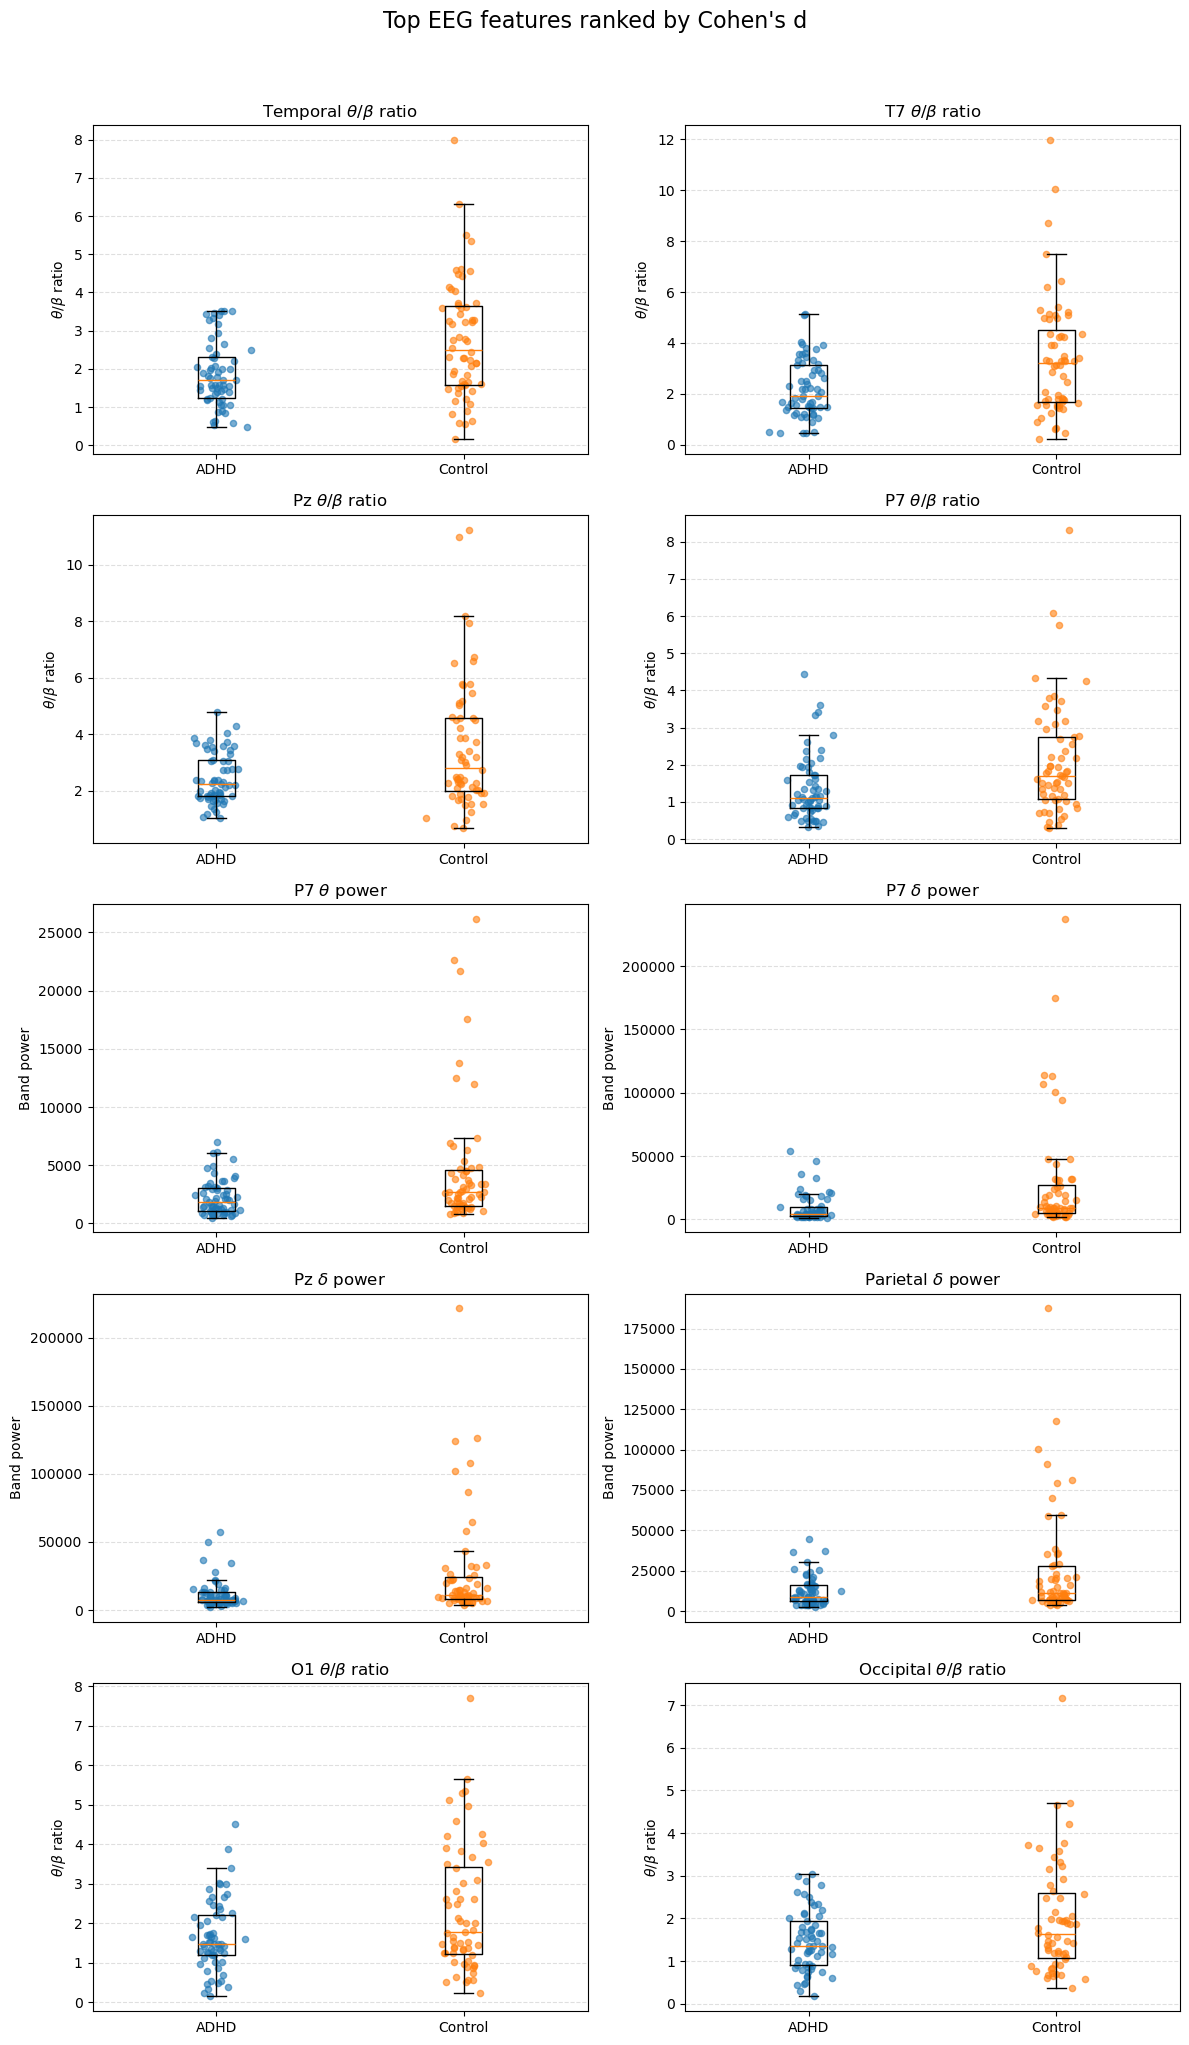

In [192]:
n_features = len(top_cohen_features)
n_cols = 2
n_rows = int(np.ceil(n_features / n_cols)) # calculate number of rows needed for 2 columns

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 4 * n_rows)
)

fig.suptitle(
    "Top EEG features ranked by Cohen's d",
    fontsize=16,
    y=1.02
)

axes = np.array(axes).flatten() 

for ax, feature in zip(axes, top_cohen_features):

    adhd = features_df.loc[
        features_df["Class"] == "ADHD",
        feature
    ]

    control = features_df.loc[
        features_df["Class"] == "Control",
        feature
    ]

    data = [adhd, control]

    ax.boxplot(
        data,
        tick_labels=["ADHD", "Control"],
        showfliers=False
    )

    for i, values in enumerate(data, start=1):

        x = np.random.normal(
            loc=i,
            scale=0.04,
            size=len(values)
        )

        ax.scatter(
            x,
            values,
            alpha=0.6,
            s=20
        )

    ax.set_title(pretty_feature_name(feature))
    ax.set_ylabel(feature_ylabel(feature))

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    ax.set_axisbelow(True)

for ax in axes[n_features:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

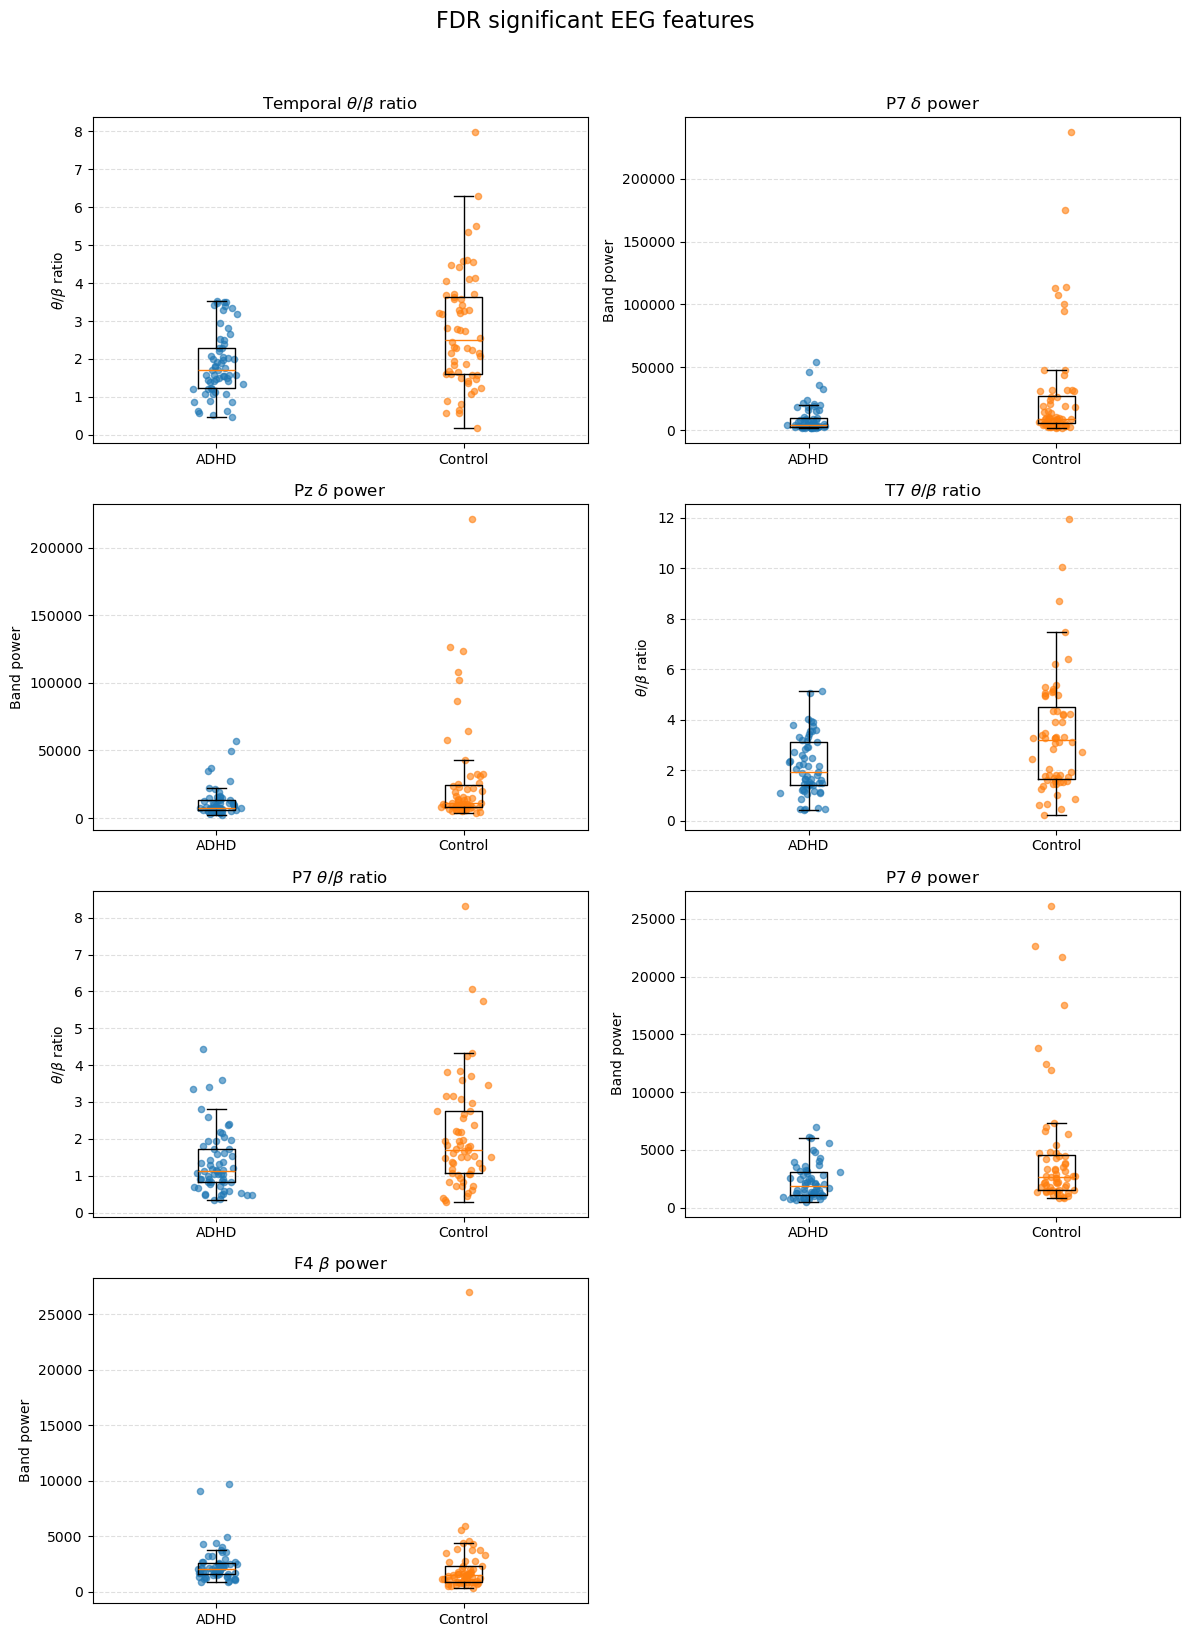

In [193]:
n_features = len(fdr_features)
n_cols = 2
n_rows = int(np.ceil(n_features / n_cols)) # calculate number of rows needed for 2 columns

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 4 * n_rows)
)

fig.suptitle(
    "FDR significant EEG features",
    fontsize=16,
    y=1.02
)

axes = np.array(axes).flatten() 

for ax, feature in zip(axes, fdr_features):

    adhd = features_df.loc[
        features_df["Class"] == "ADHD",
        feature
    ]

    control = features_df.loc[
        features_df["Class"] == "Control",
        feature
    ]

    data = [adhd, control]

    ax.boxplot(
        data,
        tick_labels=["ADHD", "Control"],
        showfliers=False
    )

    for i, values in enumerate(data, start=1):

        x = np.random.normal(
            loc=i,
            scale=0.04,
            size=len(values)
        )

        ax.scatter(
            x,
            values,
            alpha=0.6,
            s=20
        )

    ax.set_title(pretty_feature_name(feature))
    ax.set_ylabel(feature_ylabel(feature))

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    ax.set_axisbelow(True)

for ax in axes[n_features:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [194]:
# Regional effect size matrix: regions x feature types

regions = [
    "frontal",
    "central",
    "temporal",
    "parietal",
    "occipital"
]

regional_feature_types = {
    r"$\delta$ power": "delta_power_mean",
    r"$\theta$ power": "theta_power_mean",
    r"$\alpha$ power": "alpha_power_mean",
    r"$\beta$ power": "beta_power_mean",
    r"$\theta/\beta$ ratio": "theta_beta_ratio"
}

regional_cohen_matrix = pd.DataFrame(
    index=regions,
    columns=regional_feature_types.keys(),
    dtype=float
)

regional_fdr_matrix = pd.DataFrame(
    index=regions,
    columns=regional_feature_types.keys(),
    dtype=float
)

for region in regions:
    for label, suffix in regional_feature_types.items():

        feature_name = f"{region}_{suffix}"

        row = all_results_df.loc[
            all_results_df["feature"] == feature_name
        ]

        if not row.empty:
            regional_cohen_matrix.loc[region, label] = row["cohen_d"].iloc[0]
            regional_fdr_matrix.loc[region, label] = row["p_fdr"].iloc[0]

display(regional_cohen_matrix)

,$\delta$ power,$\theta$ power,$\alpha$ power,$\beta$ power,$\theta/\beta$ ratio
frontal,-0.355739,-0.109212,-0.035182,0.035712,-0.266654
central,-0.368334,-0.199566,-0.021074,-0.108592,-0.350458
temporal,-0.411385,-0.361198,-0.088524,-0.010079,-0.717449
parietal,-0.533981,-0.431235,-0.108034,-0.212050,-0.429555
occipital,-0.477615,-0.315500,0.050435,0.047358,-0.483661


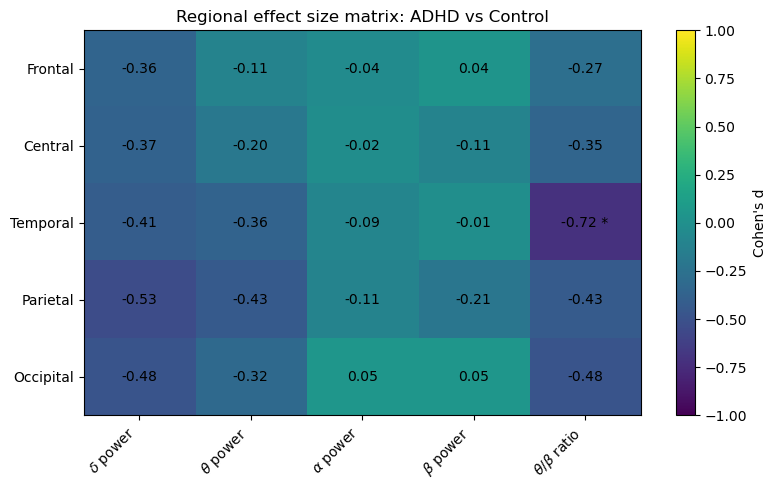

In [195]:
# Plot regional effect size matrix

plt.figure(figsize=(8, 5))

values = regional_cohen_matrix.values.astype(float)
vmax = np.nanmax(np.abs(values))

plt.imshow(
    values,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Cohen's d")

plt.xticks(
    ticks=np.arange(len(regional_cohen_matrix.columns)),
    labels=regional_cohen_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(regional_cohen_matrix.index)),
    labels=[region.capitalize() for region in regional_cohen_matrix.index]
)

# Add Cohen's d values inside each cell
for i in range(regional_cohen_matrix.shape[0]):
    for j in range(regional_cohen_matrix.shape[1]):

        value = regional_cohen_matrix.iloc[i, j]
        p_fdr = regional_fdr_matrix.iloc[i, j]

        if not np.isnan(value):
            text = f"{value:.2f}"

            if p_fdr < 0.05:
                text += " *"

            plt.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=10
            )

plt.title("Regional effect size matrix: ADHD vs Control")
plt.tight_layout()
plt.show()

In [196]:
# Channel-level effect size matrix: channels x feature types

channel_order = [
    "Fp1", "Fp2",
    "F7", "F3", "Fz", "F4", "F8",
    "T7", "C3", "Cz", "C4", "T8",
    "P7", "P3", "Pz", "P4", "P8",
    "O1", "O2"
]

channel_feature_types = {
    r"$\delta$ power": "delta_power",
    r"$\theta$ power": "theta_power",
    r"$\alpha$ power": "alpha_power",
    r"$\beta$ power": "beta_power",
    r"$\theta/\beta$ ratio": "theta_beta_ratio"
}

channel_cohen_matrix = pd.DataFrame(
    index=channel_order,
    columns=channel_feature_types.keys(),
    dtype=float
)

channel_fdr_matrix = pd.DataFrame(
    index=channel_order,
    columns=channel_feature_types.keys(),
    dtype=float
)

for channel in channel_order:
    for label, suffix in channel_feature_types.items():

        feature_name = f"{channel}_{suffix}"

        row = all_results_df.loc[
            all_results_df["feature"] == feature_name
        ]

        if not row.empty:
            channel_cohen_matrix.loc[channel, label] = row["cohen_d"].iloc[0]
            channel_fdr_matrix.loc[channel, label] = row["p_fdr"].iloc[0]

display(channel_cohen_matrix)

,$\delta$ power,$\theta$ power,$\alpha$ power,$\beta$ power,$\theta/\beta$ ratio
Fp1,-0.272226,-0.017529,-0.027780,-0.006119,-0.015065
Fp2,0.008279,0.164994,0.005292,0.049167,0.036282
F7,-0.466166,-0.408214,-0.174018,-0.107883,-0.374911
F3,-0.448637,-0.227650,-0.043971,-0.016154,-0.423718
Fz,-0.383307,-0.000302,0.116857,0.193612,-0.447361
F4,-0.209057,-0.042752,0.027875,0.060098,-0.450784
F8,-0.241903,-0.194272,-0.169463,-0.096840,-0.226320
T7,-0.463482,-0.416413,-0.121398,-0.017993,-0.657292
C3,-0.353787,-0.235580,-0.012172,0.028312,-0.430358
Cz,-0.266883,-0.150440,-0.021752,-0.175640,-0.275970


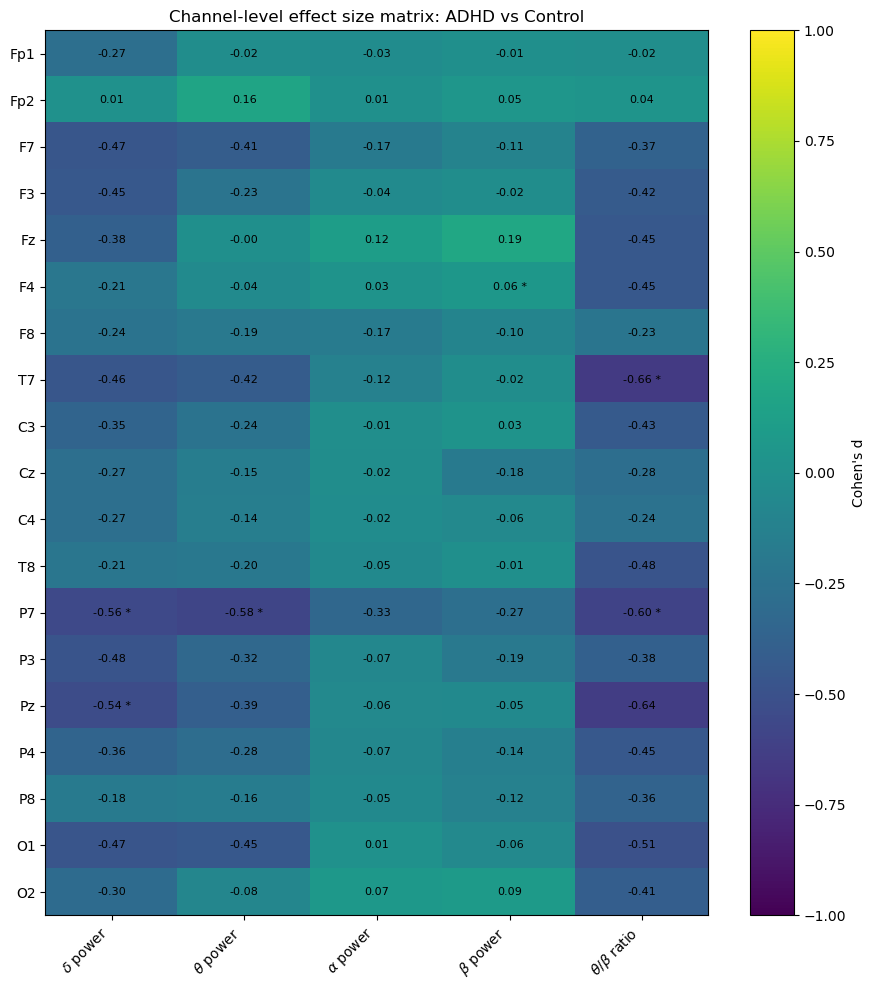

In [197]:
# Plot channel-level effect size matrix

plt.figure(figsize=(9, 10))

values = channel_cohen_matrix.values.astype(float)
vmax = np.nanmax(np.abs(values))

plt.imshow(
    values,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Cohen's d")

plt.xticks(
    ticks=np.arange(len(channel_cohen_matrix.columns)),
    labels=channel_cohen_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(channel_cohen_matrix.index)),
    labels=channel_cohen_matrix.index
)

# Add Cohen's d values inside each cell
for i in range(channel_cohen_matrix.shape[0]):
    for j in range(channel_cohen_matrix.shape[1]):

        value = channel_cohen_matrix.iloc[i, j]
        p_fdr = channel_fdr_matrix.iloc[i, j]

        if not np.isnan(value):
            text = f"{value:.2f}"

            if p_fdr < 0.05:
                text += " *"

            plt.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=8
            )

plt.title("Channel-level effect size matrix: ADHD vs Control")
plt.tight_layout()
plt.show()

### 3d. Correlation matrix across all EEG features

Spearman correlation was used instead of Pearson correlation because EEG-derived features may not be normally distributed and may contain outliers. Spearman correlation measures whether two variables tend to increase or decrease together in a monotonic way, based on their ranks rather than on their raw values.

The Spearman correlation coefficient ranges from -1 to 1:

$$
\rho = 1
$$

indicates a perfect positive monotonic relationship,

$$
\rho = -1
$$

indicates a perfect negative monotonic relationship, and

$$
\rho = 0
$$

indicates no monotonic relationship.

This analysis does not compare ADHD and Control subjects directly. Instead, it investigates how similar or redundant the extracted features are across all subjects.

In [220]:
# Select EEG features for correlation analysis

metadata_cols = [
    "ID",
    "Class",
    "n_samples",
    "duration_sec"
]

eeg_feature_cols = [
    c for c in features_df.columns
    if c not in metadata_cols
]

# Keep only numeric columns
eeg_feature_cols = [
    c for c in eeg_feature_cols
    if pd.api.types.is_numeric_dtype(features_df[c])
]

print("Number of EEG features used for correlation:", len(eeg_feature_cols))

Number of EEG features used for correlation: 120


In [221]:
# Spearman correlation matrix across all EEG features

all_feature_corr = features_df[eeg_feature_cols].corr(
    method="spearman"
)

print("Correlation matrix shape:", all_feature_corr.shape)

display(all_feature_corr)

Correlation matrix shape: (120, 120)


,Fp1_delta_power,Fp1_theta_power,Fp1_alpha_power,Fp1_beta_power,Fp1_theta_beta_ratio,Fp2_delta_power,Fp2_theta_power,Fp2_alpha_power,Fp2_beta_power,Fp2_theta_beta_ratio,...,temporal_delta_power_mean,temporal_theta_power_mean,temporal_alpha_power_mean,temporal_beta_power_mean,temporal_theta_beta_ratio,occipital_delta_power_mean,occipital_theta_power_mean,occipital_alpha_power_mean,occipital_beta_power_mean,occipital_theta_beta_ratio
Fp1_delta_power,1.000000,0.779671,0.510649,0.279603,0.551653,0.698056,0.623134,0.413562,0.156679,0.502710,...,0.346843,0.360791,0.268331,0.158630,0.224820,0.490848,0.343592,0.290604,0.326636,0.092562
Fp1_theta_power,0.779671,1.000000,0.745678,0.448090,0.588911,0.649512,0.788613,0.615100,0.311042,0.506883,...,0.178878,0.506368,0.429136,0.324421,0.201524,0.317552,0.382496,0.397541,0.429556,0.038179
Fp1_alpha_power,0.510649,0.745678,1.000000,0.555643,0.258407,0.390963,0.622260,0.788714,0.412742,0.241546,...,0.058088,0.369584,0.643246,0.455338,-0.047107,0.183322,0.296538,0.588613,0.436323,-0.072985
Fp1_beta_power,0.279603,0.448090,0.555643,1.000000,-0.393063,0.260236,0.417349,0.503157,0.728865,-0.231215,...,0.075870,0.297256,0.323818,0.541803,-0.140523,0.162796,0.257221,0.409436,0.480416,-0.137725
Fp1_theta_beta_ratio,0.551653,0.588911,0.258407,-0.393063,1.000000,0.413291,0.405040,0.169930,-0.322443,0.746274,...,0.197880,0.317647,0.165133,-0.138050,0.428092,0.252642,0.227266,0.068581,0.019191,0.230612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
occipital_delta_power_mean,0.490848,0.317552,0.183322,0.162796,0.252642,0.349133,0.243836,0.203367,0.102771,0.155975,...,0.691946,0.608163,0.304667,0.171230,0.476284,1.000000,0.830816,0.485469,0.262451,0.545759
occipital_theta_power_mean,0.343592,0.382496,0.296538,0.257221,0.227266,0.291410,0.282739,0.304186,0.156388,0.145888,...,0.561543,0.707567,0.461943,0.245177,0.497744,0.830816,1.000000,0.682828,0.323784,0.622436
occipital_alpha_power_mean,0.290604,0.397541,0.588613,0.409436,0.068581,0.279867,0.373852,0.587624,0.331303,0.073554,...,0.239378,0.438504,0.647839,0.413365,0.067951,0.485469,0.682828,1.000000,0.564497,0.159064
occipital_beta_power_mean,0.326636,0.429556,0.436323,0.480416,0.019191,0.319449,0.396925,0.451626,0.487278,-0.029888,...,0.171061,0.278302,0.320377,0.468107,-0.124482,0.262451,0.323784,0.564497,1.000000,-0.463596


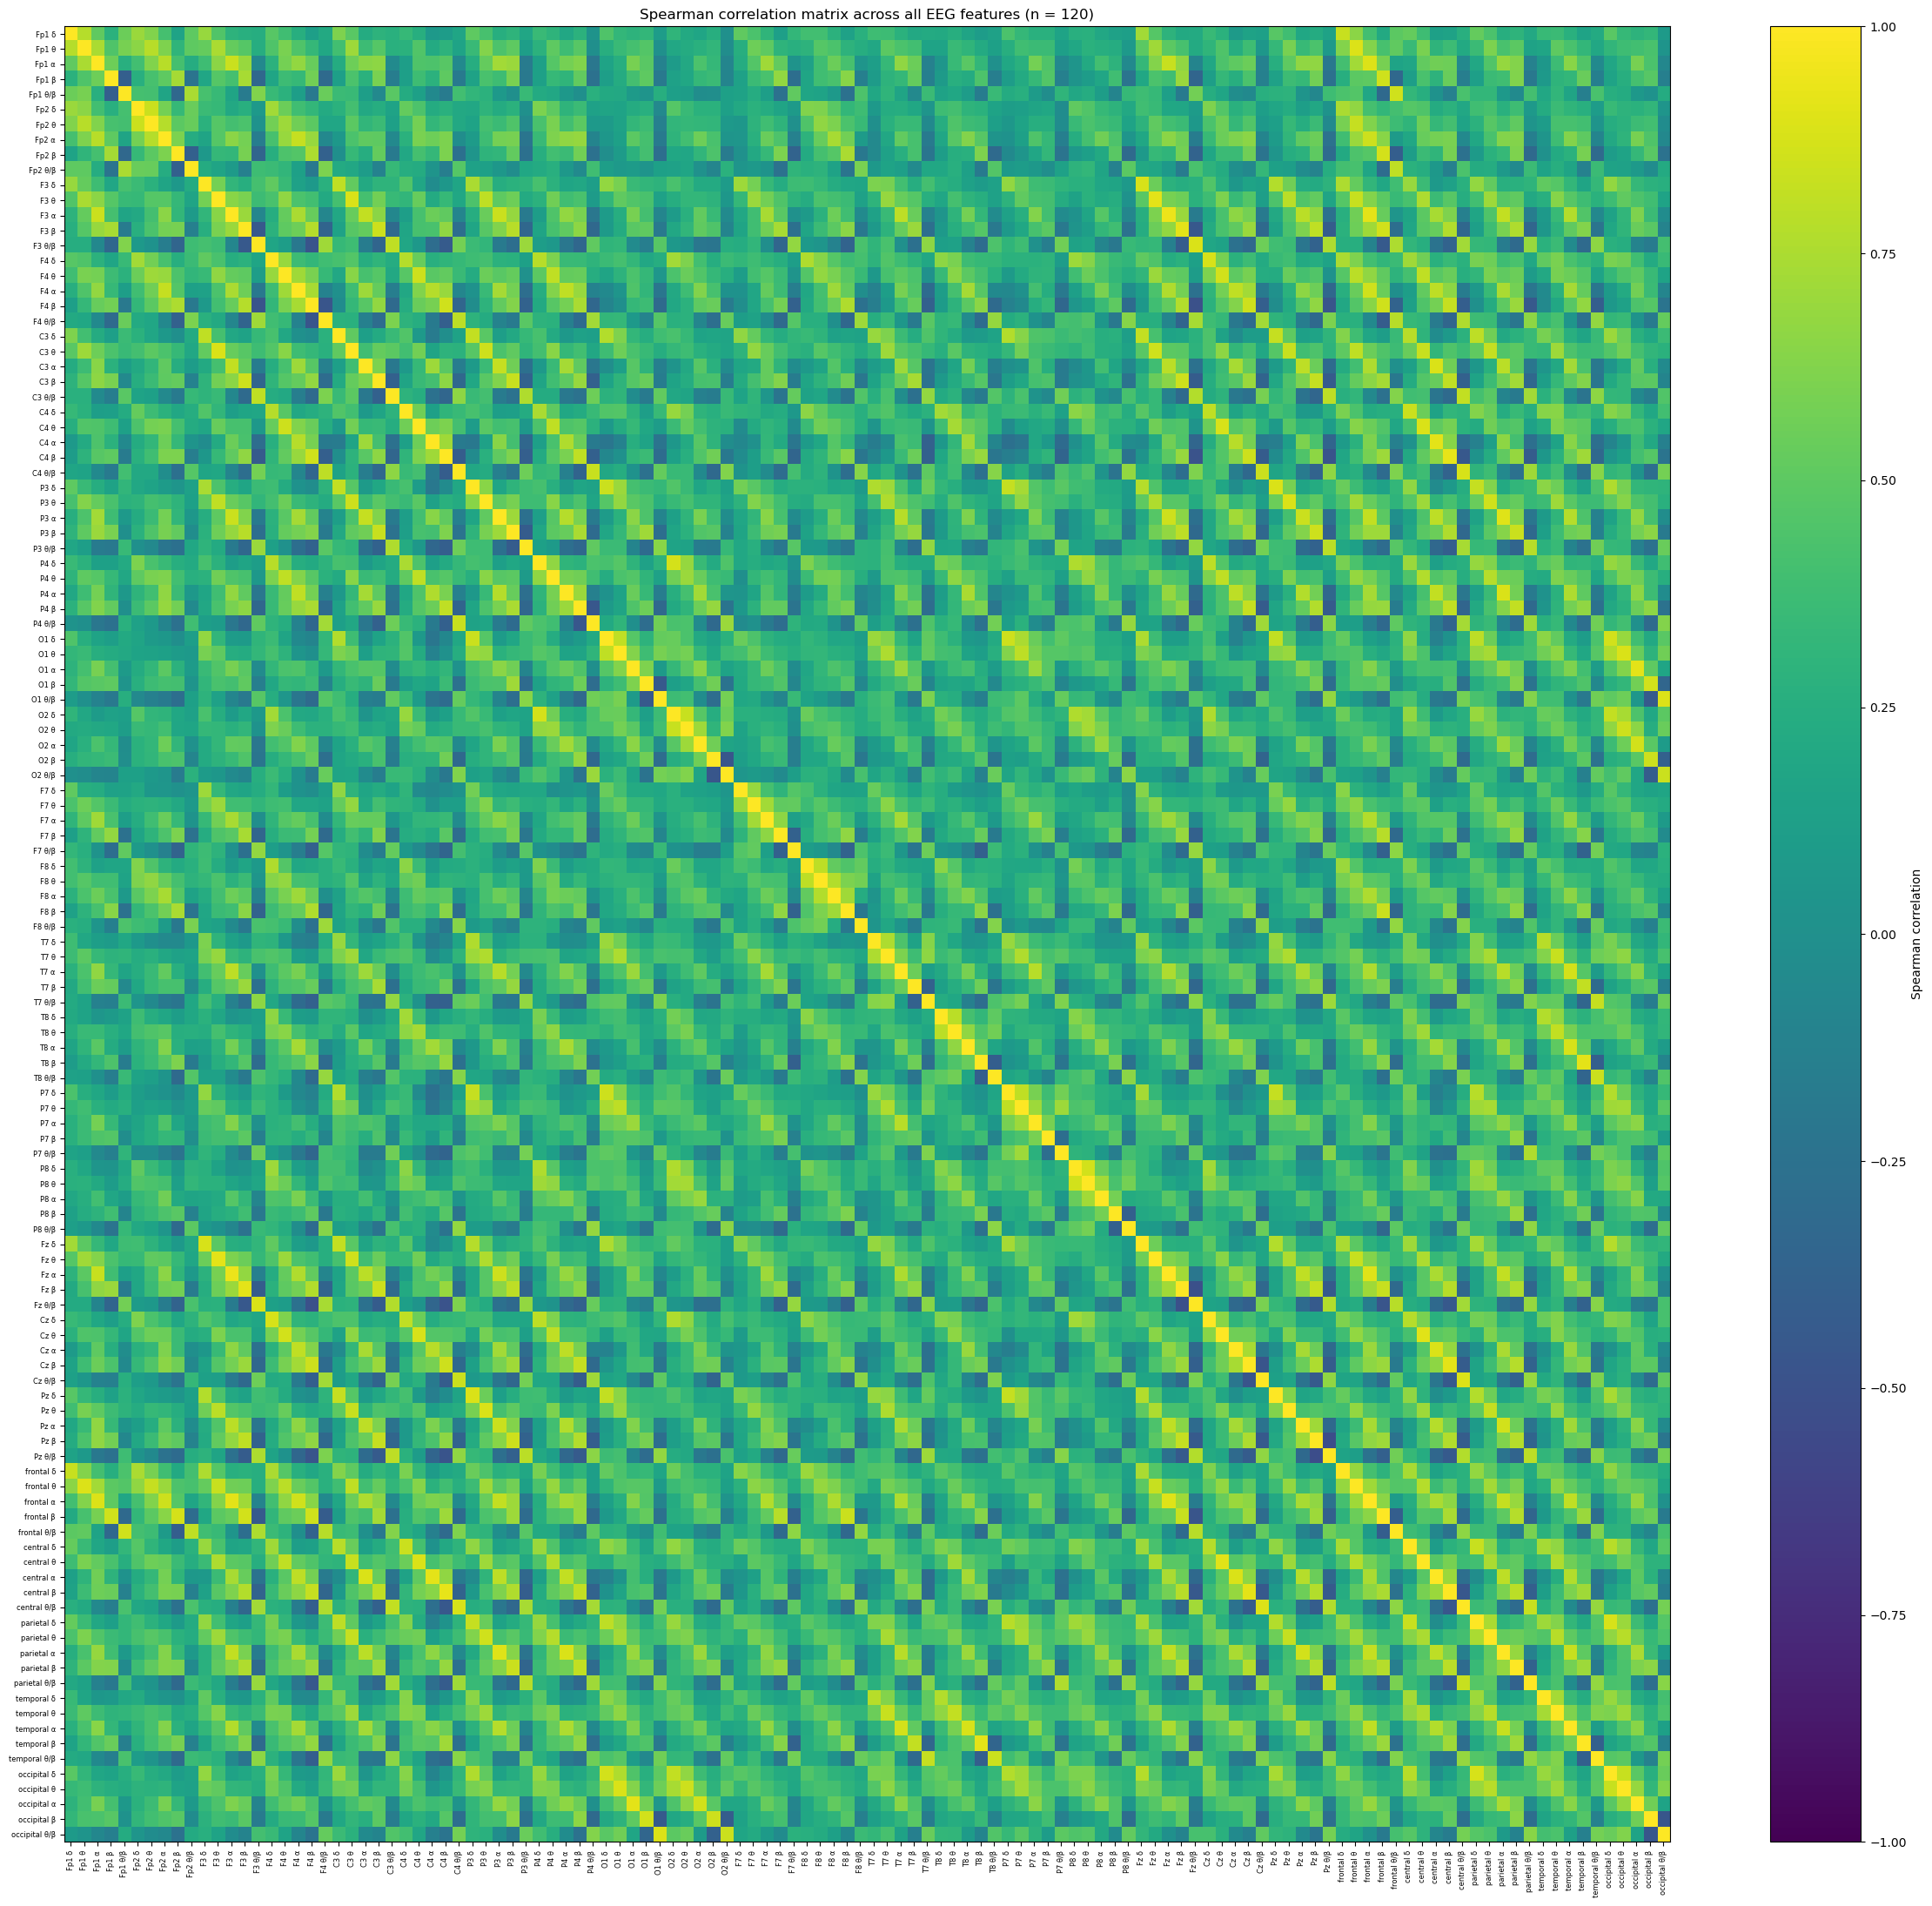

In [226]:
# Plot full correlation matrix with feature names
def short_feature_name(feature):
    """
    Create shorter labels for correlation matrix axes.
    """
    name = feature

    name = name.replace("_power_mean", "")
    name = name.replace("_power", "")
    name = name.replace("_theta_beta_ratio", "_θ/β")

    name = name.replace("delta", "δ")
    name = name.replace("theta", "θ")
    name = name.replace("alpha", "α")
    name = name.replace("beta", "β")

    name = name.replace("_", " ")

    return name
plt.figure(figsize=(24, 22))

plt.imshow(
    all_feature_corr.values,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Spearman correlation")

feature_labels = [
    short_feature_name(feature)
    for feature in all_feature_corr.columns
]

plt.xticks(
    ticks=np.arange(len(feature_labels)),
    labels=feature_labels,
    rotation=90,
    fontsize=6
)

plt.yticks(
    ticks=np.arange(len(feature_labels)),
    labels=feature_labels,
    fontsize=6
)

plt.title(
    f"Spearman correlation matrix across all EEG features (n = {len(eeg_feature_cols)})"
)

plt.tight_layout()
plt.show()

In [223]:
# Extract strongest feature-feature correlations

corr_pairs = []

for i, feature_1 in enumerate(all_feature_corr.columns):
    for j, feature_2 in enumerate(all_feature_corr.columns):

        # Avoid duplicate pairs and self-correlations
        if j <= i:
            continue

        corr_value = all_feature_corr.loc[
            feature_1,
            feature_2
        ]

        corr_pairs.append({
            "feature_1": feature_1,
            "feature_2": feature_2,
            "spearman_r": corr_value,
            "abs_spearman_r": abs(corr_value)
        })

corr_pairs_df = pd.DataFrame(corr_pairs)

corr_pairs_df = corr_pairs_df.sort_values(
    "abs_spearman_r",
    ascending=False
)

display(corr_pairs_df.head(30))

,feature_1,feature_2,spearman_r,abs_spearman_r
1431,F3_alpha_power,Fz_alpha_power,0.939656,0.939656
3028,C4_beta_power,central_beta_power_mean,0.928546,0.928546
6658,Cz_beta_power,central_beta_power_mean,0.921582,0.921582
4211,O1_alpha_power,occipital_alpha_power_mean,0.919137,0.919137
1323,F3_theta_power,Fz_theta_power,0.918500,0.918500
1538,F3_beta_power,Fz_beta_power,0.916962,0.916962
5858,T8_beta_power,temporal_beta_power_mean,0.915777,0.915777
2936,C4_alpha_power,central_alpha_power_mean,0.915662,0.915662
1446,F3_alpha_power,frontal_alpha_power_mean,0.915567,0.915567
6593,Cz_theta_power,central_theta_power_mean,0.907662,0.907662


In [224]:
# Strongest positive correlations

strongest_positive_corr = corr_pairs_df.sort_values(
    "spearman_r",
    ascending=False
).head(20)

display(strongest_positive_corr)

,feature_1,feature_2,spearman_r,abs_spearman_r
1431,F3_alpha_power,Fz_alpha_power,0.939656,0.939656
3028,C4_beta_power,central_beta_power_mean,0.928546,0.928546
6658,Cz_beta_power,central_beta_power_mean,0.921582,0.921582
4211,O1_alpha_power,occipital_alpha_power_mean,0.919137,0.919137
1323,F3_theta_power,Fz_theta_power,0.918500,0.918500
1538,F3_beta_power,Fz_beta_power,0.916962,0.916962
5858,T8_beta_power,temporal_beta_power_mean,0.915777,0.915777
2936,C4_alpha_power,central_alpha_power_mean,0.915662,0.915662
1446,F3_alpha_power,frontal_alpha_power_mean,0.915567,0.915567
6593,Cz_theta_power,central_theta_power_mean,0.907662,0.907662


In [225]:
# Strongest negative correlations

strongest_negative_corr = corr_pairs_df.sort_values(
    "spearman_r",
    ascending=True
).head(20)

display(strongest_negative_corr)

,feature_1,feature_2,spearman_r,abs_spearman_r
6789,Pz_beta_power,Pz_theta_beta_ratio,-0.529190,0.529190
6474,Fz_beta_power,Fz_theta_beta_ratio,-0.515242,0.515242
2054,F4_beta_power,Fz_theta_beta_ratio,-0.501307,0.501307
3009,C4_beta_power,Fz_theta_beta_ratio,-0.490184,0.490184
3019,C4_beta_power,Pz_theta_beta_ratio,-0.478777,0.478777
1578,F3_theta_beta_ratio,F4_beta_power,-0.478018,0.478018
2064,F4_beta_power,Pz_theta_beta_ratio,-0.474495,0.474495
1989,F4_beta_power,F4_theta_beta_ratio,-0.473290,0.473290
6644,Cz_beta_power,Cz_theta_beta_ratio,-0.470397,0.470397
6523,Fz_theta_beta_ratio,frontal_beta_power_mean,-0.468941,0.468941
